# ResNet50 + Bilateral Filter — 12-class Garbage Classification

**Dataset:** `garbage_dataset_12class.zip` (15,493 images, 12 classes: battery, biological, brown-glass, cardboard, clothes, green-glass, metal, paper, plastic, shoes, trash, white-glass)

**Before running:** upload the zip to the root of your Google Drive, then *Runtime → Change runtime type → T4 GPU*, then *Run all*.

In [1]:
##########################################
# 0. Install Dependencies
##########################################
!pip install -q opencv-python

##########################################
# 1. Imports
##########################################
import os
import cv2
import numpy as np
import torch
import torchvision
from torch.utils.data import random_split, DataLoader
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import CosineAnnealingLR

In [2]:
##########################################
# 2. BilateralFilterTransform
##########################################
class BilateralFilterTransform:
    """
    A custom transform applying a mild bilateral filter
    to reduce noise while preserving edges.
    """
    def __init__(self, d=3, sigmaColor=50, sigmaSpace=50):
        """
        d: Diameter of each pixel neighborhood (3 is small/light).
        sigmaColor: Filter sigma in color space.
        sigmaSpace: Filter sigma in coordinate space.
        """
        self.d = d
        self.sigmaColor = sigmaColor
        self.sigmaSpace = sigmaSpace

    def __call__(self, pil_img):
        """
        pil_img: a PIL image from the dataset.
        Returns a PIL image after applying bilateral filtering.
        """
        # Convert PIL -> NumPy -> OpenCV
        img_np = np.array(pil_img)

        if len(img_np.shape) == 2:
            # Grayscale
            filtered = cv2.bilateralFilter(img_np, self.d, self.sigmaColor, self.sigmaSpace)
        else:
            # Color image
            img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
            filtered_bgr = cv2.bilateralFilter(img_bgr, self.d, self.sigmaColor, self.sigmaSpace)
            filtered = cv2.cvtColor(filtered_bgr, cv2.COLOR_BGR2RGB)

        # Convert back to PIL
        return transforms.functional.to_pil_image(filtered)


In [4]:
##########################################
# 3. Data Extraction (Google Drive zip -> local Colab disk)
##########################################
import os, zipfile
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

# >>> Upload garbage_dataset_12class.zip to the ROOT of your Google Drive (My Drive) <<<
ZIP_PATH   = '/content/drive/MyDrive/garbage_dataset_12class.zip'
EXTRACT_TO = '/content/dataset'          # local disk = much faster than reading from Drive

if not os.path.isdir(EXTRACT_TO) or not os.listdir(EXTRACT_TO):
    if not os.path.exists(ZIP_PATH):
        raise FileNotFoundError(f"{ZIP_PATH} not found. Upload the zip to the root of My Drive "
                                f"(or change ZIP_PATH above).")
    print("Unzipping dataset (takes ~1 min)...")
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(EXTRACT_TO)

def find_class_root(path):
    """Walk down through single wrapper folders until we reach the folder that
    directly contains the class folders (battery/, cardboard/, ...)."""
    while True:
        subs = [d for d in sorted(os.listdir(path))
                if os.path.isdir(os.path.join(path, d)) and not d.startswith(('.', '__'))]
        if len(subs) == 1:
            path = os.path.join(path, subs[0])
        else:
            return path

data_path = find_class_root(EXTRACT_TO)
categories = sorted(d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d)))
print("Dataset root :", data_path)
print("Categories   :", categories)

# Safety check: catches the 'train'/'test' nesting problem from the old CAPSTONE_CNN zip
assert not ({c.lower() for c in categories} & {'train', 'test', 'val', 'valid', 'validation'}), \
    "Found train/test/val folders instead of class folders - the dataset is nested wrongly."
assert len(categories) >= 2, "Expected at least 2 class folders."

Unzipping dataset (takes ~1 min)...
Dataset root : /content/dataset/garbage_dataset_12class
Categories   : ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


In [5]:
##########################################
# 4. Data Augmentation & Dataset
##########################################
# We'll add bilateral filtering only to training transforms.
train_transforms = transforms.Compose([
    BilateralFilterTransform(d=3, sigmaColor=50, sigmaSpace=50),  # mild bilateral filter
    transforms.Resize((256,256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [6]:
# For validation & test, no random transforms, no bilateral filtering
val_test_transforms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load dataset (used here for class names + labels; transforms are attached in the next cell)
full_dataset = ImageFolder(data_path)
class_names = full_dataset.classes
num_classes = len(class_names)
print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Total images:", len(full_dataset))

Classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']
Number of classes: 12
Total images: 15493


In [7]:
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
from collections import Counter

seed = 42
torch.manual_seed(seed)

# Stratified 80/10/10 split -> every class appears in train/val/test in the same proportion
# (important here: 'clothes' has 5,324 images but 'trash' only 697).
targets = np.array(full_dataset.targets)
all_idx = np.arange(len(targets))
train_idx, tmp_idx = train_test_split(all_idx, test_size=0.2, stratify=targets, random_state=seed)
val_idx, test_idx  = train_test_split(tmp_idx, test_size=0.5, stratify=targets[tmp_idx], random_state=seed)
print(f"Total images: {len(targets)} (Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)})")

# Two ImageFolder objects so train gets augmentation + bilateral filter and val/test do NOT.
# (random_split on one shared dataset would give all three splits the same transform.)
train_ds = ImageFolder(data_path, transform=train_transforms)
eval_ds  = ImageFolder(data_path, transform=val_test_transforms)

train_set = Subset(train_ds, train_idx)
val_set   = Subset(eval_ds,  val_idx)
test_set  = Subset(eval_ds,  test_idx)

print("\nImages per class (train / val / test):")
for i, name in enumerate(class_names):
    print(f"  {name:<12} {(targets[train_idx]==i).sum():>5} / {(targets[val_idx]==i).sum():>4} / {(targets[test_idx]==i).sum():>4}")

batch_size = 32
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=batch_size*2, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=batch_size*2, shuffle=False, num_workers=2, pin_memory=True)

Total images: 15493 (Train: 12394, Val: 1549, Test: 1550)

Images per class (train / val / test):
  battery        756 /   94 /   95
  biological     788 /   98 /   99
  brown-glass    486 /   61 /   60
  cardboard      713 /   89 /   89
  clothes       4259 /  532 /  533
  green-glass    491 /   62 /   61
  metal          614 /   77 /   77
  paper          840 /  105 /  105
  plastic        690 /   86 /   87
  shoes         1581 /  198 /  198
  trash          558 /   70 /   69
  white-glass    618 /   77 /   77


Sample batch from training set (with BilateralFilter):


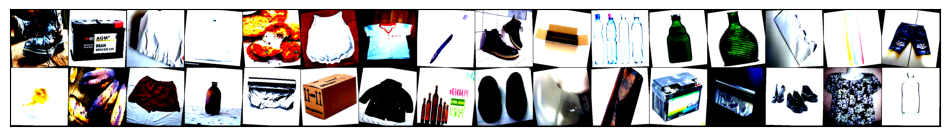

In [8]:
def display_batch(dl):
    for imgs, lbls in dl:
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(torchvision.utils.make_grid(imgs, nrow=16).permute(1,2,0))
        plt.show()
        break

print("Sample batch from training set (with BilateralFilter):")
display_batch(train_loader)

In [9]:
##########################################
# 5. Define a Simple ResNet50 Model
##########################################
class ResNet50Modified(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50Modified, self).__init__()
        self.network = models.resnet50(weights="IMAGENET1K_V2")

        # Replace final FC layers
        num_ftrs = self.network.fc.in_features
        self.network.fc = nn.Sequential(
            nn.Linear(num_ftrs, 500),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(500, 200),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(200, num_classes)
        )

    def forward(self, x):
        return self.network(x)

def freeze_layers(model, freeze_until=0):
    """
    freeze_until=0 => unfreeze all layers
    freeze_until=6 => freeze more layers
    etc.
    """
    child_counter = 0
    for child in model.network.children():
        child_counter += 1
        if child_counter < freeze_until:
            for param in child.parameters():
                param.requires_grad = False
    return model

In [10]:
##########################################
# 6. Training & Validation
##########################################
def train_model(epochs, model, train_loader, val_loader, optimizer, scheduler, criterion, device):
    history = []
    for epoch in range(epochs):
        model.train()
        train_losses = []
        train_correct = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
            optimizer.step()
            train_losses.append(loss.item())

            _, preds = torch.max(outputs, dim=1)
            train_correct += (preds == labels).sum().item()
            total_train += labels.size(0)

        train_loss_avg = sum(train_losses) / len(train_losses)
        train_acc = train_correct / total_train

        # Validation
        model.eval()
        val_losses = []
        val_correct = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss = criterion(outputs, labels)
                val_losses.append(val_loss.item())

                _, preds = torch.max(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                total_val += labels.size(0)

        val_loss_avg = sum(val_losses) / len(val_losses)
        val_acc = val_correct / total_val

        scheduler.step()  # CosineAnnealingLR typically updates each epoch

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss_avg:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss_avg:.4f} | Val Acc: {val_acc:.4f}")

        history.append({
            'epoch': epoch+1,
            'train_loss': train_loss_avg,
            'train_acc': train_acc,
            'val_loss': val_loss_avg,
            'val_acc': val_acc
        })
    return history

In [11]:
##########################################
# 7. Main: Instantiate & Train
##########################################
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNet50Modified(num_classes=num_classes).to(device)

# Optionally freeze or unfreeze layers
# If your dataset is large, unfreeze all (freeze_until=0).
# If smaller, freeze more (like freeze_until=6).
model = freeze_layers(model, freeze_until=0)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s]


Epoch 1/20 | Train Loss: 0.9950 | Train Acc: 0.8196 | Val Loss: 0.6504 | Val Acc: 0.9593
Epoch 2/20 | Train Loss: 0.6339 | Train Acc: 0.9672 | Val Loss: 0.6199 | Val Acc: 0.9658
Epoch 3/20 | Train Loss: 0.5953 | Train Acc: 0.9825 | Val Loss: 0.6072 | Val Acc: 0.9690
Epoch 4/20 | Train Loss: 0.5782 | Train Acc: 0.9885 | Val Loss: 0.6122 | Val Acc: 0.9677
Epoch 5/20 | Train Loss: 0.5693 | Train Acc: 0.9906 | Val Loss: 0.6031 | Val Acc: 0.9716
Epoch 6/20 | Train Loss: 0.5635 | Train Acc: 0.9928 | Val Loss: 0.5975 | Val Acc: 0.9748
Epoch 7/20 | Train Loss: 0.5573 | Train Acc: 0.9943 | Val Loss: 0.6130 | Val Acc: 0.9671
Epoch 8/20 | Train Loss: 0.5534 | Train Acc: 0.9963 | Val Loss: 0.6061 | Val Acc: 0.9690
Epoch 9/20 | Train Loss: 0.5538 | Train Acc: 0.9956 | Val Loss: 0.6029 | Val Acc: 0.9729
Epoch 10/20 | Train Loss: 0.5468 | Train Acc: 0.9985 | Val Loss: 0.5936 | Val Acc: 0.9748
Epoch 11/20 | Train Loss: 0.5465 | Train Acc: 0.9979 | Val Loss: 0.5889 | Val Acc: 0.9768
Epoch 12/20 | Train

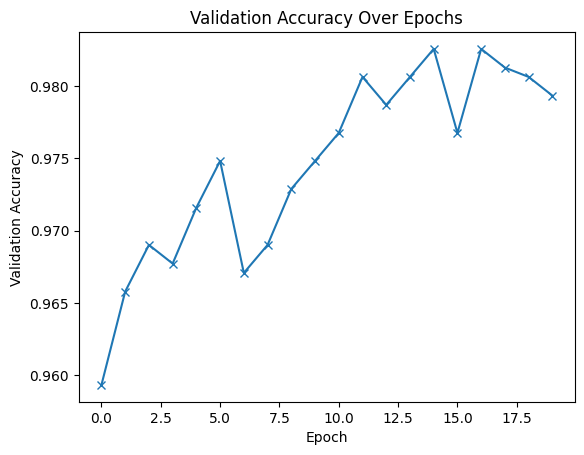

In [12]:
num_epochs = 20
history = train_model(num_epochs, model, train_loader, val_loader, optimizer, scheduler, criterion, device)

# Plot Accuracy
plt.plot([h['val_acc'] for h in history], '-x')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Over Epochs')
plt.show()

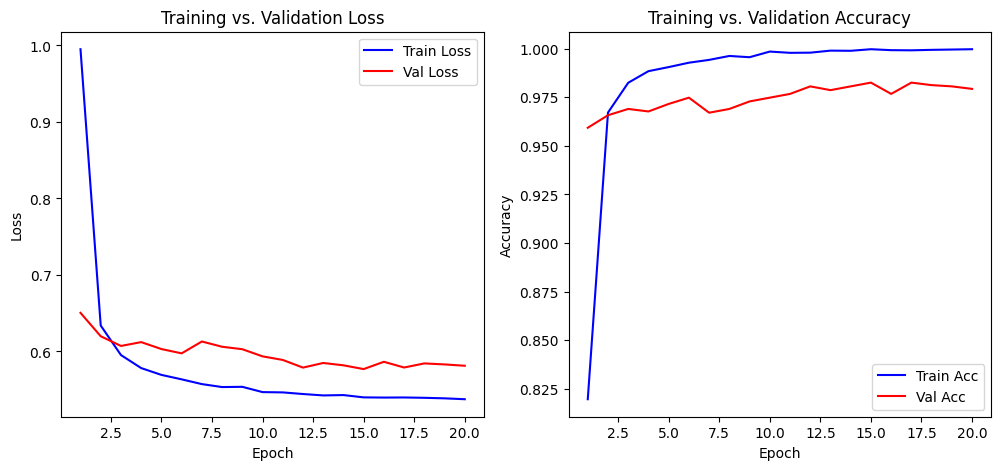

In [13]:
##########################################
# 7. Plot Training Curves
##########################################
epochs_list = [h['epoch'] for h in history]
train_acc_list = [h['train_acc'] for h in history]
val_acc_list = [h['val_acc'] for h in history]
train_loss_list = [h['train_loss'] for h in history]
val_loss_list = [h['val_loss'] for h in history]

plt.figure(figsize=(12,5))

# Loss curves
plt.subplot(1,2,1)
plt.plot(epochs_list, train_loss_list, 'b-', label='Train Loss')
plt.plot(epochs_list, val_loss_list, 'r-', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()

# Accuracy curves
plt.subplot(1,2,2)
plt.plot(epochs_list, train_acc_list, 'b-', label='Train Acc')
plt.plot(epochs_list, val_acc_list, 'r-', label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs. Validation Accuracy')
plt.legend()

plt.show()

In [14]:
# After training completes
MODEL_PATH = "resnet50_modified.pth"

# Save only the model's state_dict (recommended best practice)
torch.save(model.state_dict(), MODEL_PATH)

print(f"Model saved to {MODEL_PATH}")


Model saved to resnet50_modified.pth


In [15]:
# 8. Evaluate on Test Set
##########################################
model.eval()
test_correct = 0
total_test = 0
preds_list = []
labels_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, dim=1)
        test_correct += (preds == labels).sum().item()
        total_test += labels.size(0)

        # Collect for confusion matrix
        preds_list.extend(preds.cpu().numpy())
        labels_list.extend(labels.cpu().numpy())

test_acc = test_correct / total_test
print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 0.9819


In [16]:
# For metrics & plots
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


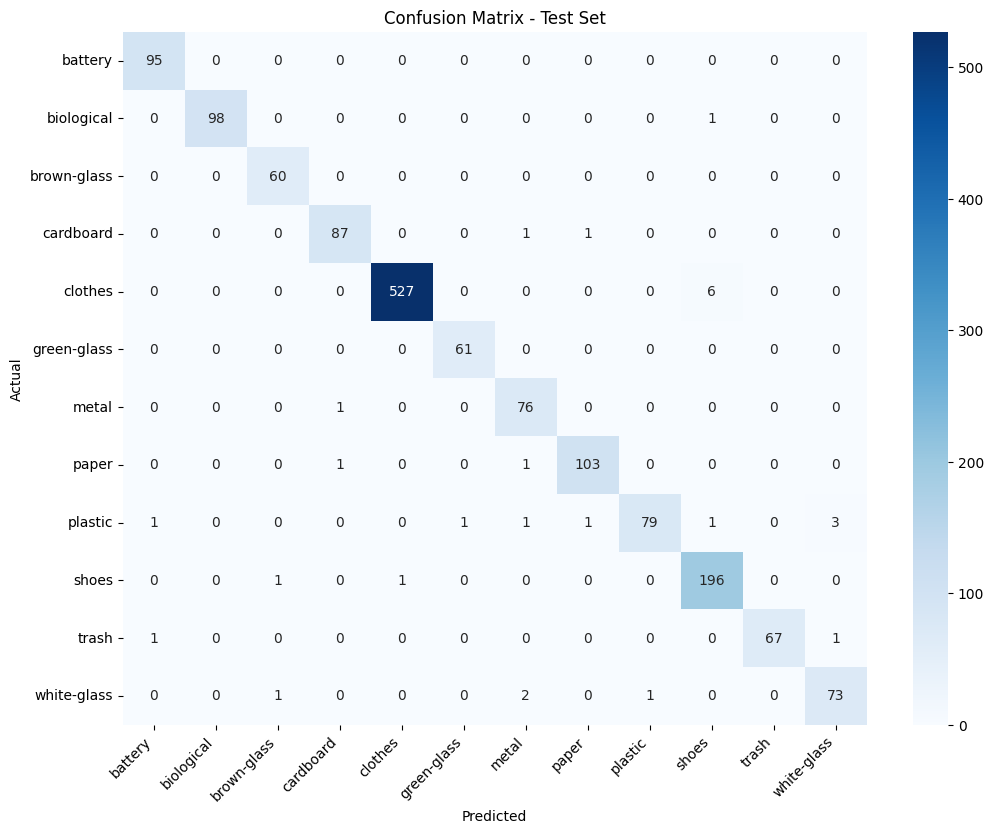

Classification Report:
              precision    recall  f1-score   support

     battery      0.979     1.000     0.990        95
  biological      1.000     0.990     0.995        99
 brown-glass      0.968     1.000     0.984        60
   cardboard      0.978     0.978     0.978        89
     clothes      0.998     0.989     0.993       533
 green-glass      0.984     1.000     0.992        61
       metal      0.938     0.987     0.962        77
       paper      0.981     0.981     0.981       105
     plastic      0.988     0.908     0.946        87
       shoes      0.961     0.990     0.975       198
       trash      1.000     0.971     0.985        69
 white-glass      0.948     0.948     0.948        77

    accuracy                          0.982      1550
   macro avg      0.977     0.978     0.977      1550
weighted avg      0.982     0.982     0.982      1550



In [17]:
##########################################
# 9. Confusion Matrix & Classification Report
##########################################
cm = confusion_matrix(labels_list, preds_list)
plt.figure(figsize=(12,9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xticks(rotation=45, ha="right")
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report:")
print(classification_report(labels_list, preds_list, target_names=class_names, digits=3))


In [18]:
!pip install captum shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 19.0 MB/s eta 0:00:00


In [19]:
##########################################
# XAI Add-On: Grad-CAM & SHAP
##########################################

import shap
from captum.attr import LayerGradCam
import torch.nn.functional as F
import cv2

In [20]:

##########################################
# 1. Grad-CAM with Captum
##########################################
# We'll pick the last convolutional layer in layer4
# For ResNet50, often it's layer4[-1].conv3
last_conv_layer = model.network.layer4[-1].conv3

gradcam = LayerGradCam(model, last_conv_layer)

def show_gradcam(model, image, label_idx, class_names):
    """
    Generates Grad-CAM heatmap for a single image & label,
    displays the original & overlay side-by-side.
    """
    model.eval()
    image_batch = image.unsqueeze(0).to(device)
    attributions = gradcam.attribute(image_batch, target=label_idx)

    # Convert attributions to a heatmap
    grad = attributions.squeeze().detach().cpu().numpy()
    grad = np.maximum(grad, 0)
    grad /= (grad.max() + 1e-8)

    # Resize heatmap to match original image
    heatmap = cv2.resize(grad, (image.shape[2], image.shape[1]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Original image to [0..1] range for blending
    img_np = image.permute(1,2,0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    img_np = np.uint8(255 * img_np)

    overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

    # Show images
    fig, ax = plt.subplots(1,2, figsize=(10,5))
    ax[0].imshow(img_np)
    ax[0].set_title(f"Original Image\n(Label: {class_names[label_idx]})")
    ax[0].axis('off')
    ax[1].imshow(overlay)
    ax[1].set_title("Grad-CAM Overlay")
    ax[1].axis('off')
    plt.show()


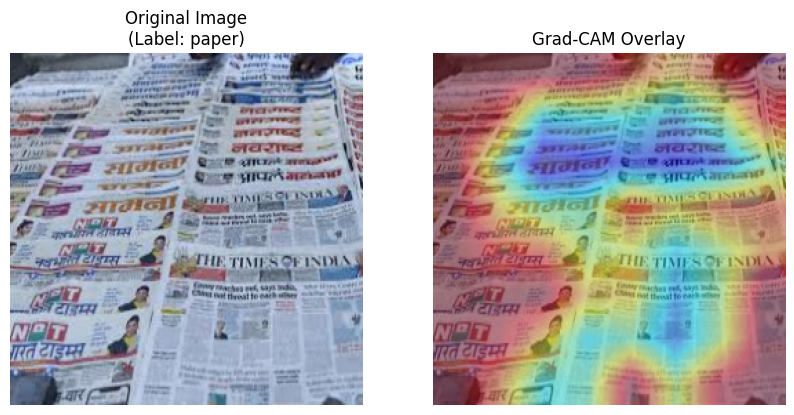

In [21]:
# Example usage on one batch from test_loader
images, labels = next(iter(test_loader))
sample_img = images[0]
sample_label = labels[0].item()
show_gradcam(model, sample_img, sample_label, class_names)


In [22]:
def flatten_4d_to_2d(images_np):
    """
    images_np shape: (N, C, H, W)
    returns flattened shape: (N, C*H*W)
    """
    N, C, H, W = images_np.shape
    return images_np.reshape(N, C*H*W)

def unflatten_2d_to_4d(shap_values_2d, N, C, H, W):
    """
    shap_values_2d shape: (N, C*H*W)
    returns shape: (N, C, H, W)
    """
    return shap_values_2d.reshape(N, C, H, W)


In [23]:
import torch.nn.functional as F

def predict_fn_flat(flat_data_np, model, device, C=3, H=256, W=256):
    """
    flat_data_np: shape (N, C*H*W)
    We unflatten -> (N, C, H, W), run model, return probabilities as numpy array.
    """
    N = flat_data_np.shape[0]
    # Unflatten
    images_4d = flat_data_np.reshape(N, C, H, W)

    # Convert to torch tensor on device
    with torch.no_grad():
        images_t = torch.tensor(images_4d, dtype=torch.float32).to(device)
        outputs = model(images_t)  # logits, shape [N, num_classes]
        probs = F.softmax(outputs, dim=1)  # convert logits to probabilities
        return probs.cpu().numpy()  # back to numpy


In [24]:
!pip install shap


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:11, 11.62s/it]               


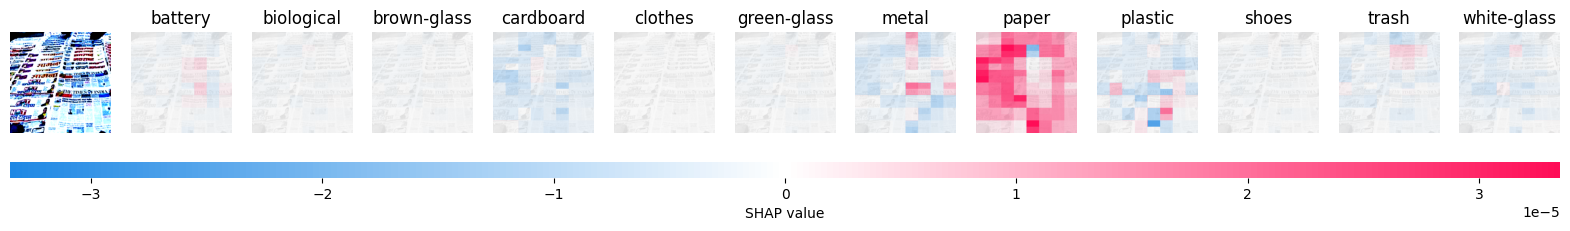

In [25]:
# 1) Build a model prediction wrapper compatible with SHAP's image explainer
def predict_wrapper(images_np):
    # images_np is input as (N, H, W, C)
    # Convert back to (N, C, H, W) PyTorch tensor
    images_t = torch.tensor(images_np.transpose(0, 3, 1, 2), dtype=torch.float32).to(device)
    with torch.no_grad():
        outputs = model(images_t)
        probs = F.softmax(outputs, dim=1)
        return probs.cpu().numpy()

# 2) Get a single test image and convert it to (H, W, C) for the image explainer
test_images, _ = next(iter(test_loader))
single_img_chw = test_images[0].numpy()
single_img_hwc = single_img_chw.transpose(1, 2, 0)

# 3) Initialize SHAP Image Explainer (which uses Partition explainer internally with blur masking)
# This is designed specifically for images and avoids the high-dimensional max_evals issue
masker = shap.maskers.Image("blur(128,128)", shape=(256, 256, 3))
explainer = shap.Explainer(predict_wrapper, masker, output_names=class_names)

# Compute SHAP values with a reasonable budget (e.g., 500 evaluations of blurred regions instead of individual pixels)
shap_values = explainer(np.expand_dims(single_img_hwc, axis=0), max_evals=500, batch_size=50)

# 4) Plot the SHAP values
shap.image_plot(shap_values)